In [35]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
import xclimate as xclim

In [3]:
time_slice = slice("1995-01", "2014-12")
year_start = time_slice.start[:4]
year_end = time_slice.stop[:4]
variables = [
    "PRECT_calculated_month_1",
    "EFLX_LH_TOT_month_1",
    "SOILLIQ_month_1",
    "SOILWATER_10CM_month_1",
    "TOTSOILLIQ_month_1",
    "TWS_month_1",
    "uIVT_month_1",
    "vIVT_month_1",
]

In [4]:
fhist_grid = xclim.load_fhist_ppe_grid()

c = "f.e21.FHIST_BGC.f19_f19_mg17.historical.coupPPE.004"
levgrnd = xr.open_dataset(f"/glade/campaign/univ/uwas0155/ppe/historical/coupled_simulations/{c}/lnd/proc/tseries/month_1/{c}.clm2.h0.SOILLIQ.195001-201412.nc").levgrnd
levsoi = levgrnd.rename(levgrnd='levsoi').isel(levsoi=slice(0,20))

In [ ]:
fhist = {}
for v in variables:
    print(v)
    name = "_".join(v.split("_")[:-2])

    fhist[v] = (
        xclim.load_fhist(v, keep_var_only=True)[name]
        .sel(time=time_slice, lat=slice(-55, None))
        .reindex_like(fhist_grid, method="nearest", tolerance=1e-3)
        # .where(fhist_grid.LANDFRAC > 0)
        .chunk({'time': -1})
    )

    if "levsoi" in fhist[v].dims:
        fhist[v] = fhist[v].assign_coords(levsoi=levsoi)
    

## Convert units ##

fhist['EFLX_LH_TOT_month_1'] = fhist['EFLX_LH_TOT_month_1'] / 2.5e6 * 86400
fhist['EFLX_LH_TOT_month_1'].attrs['units'] = "mm/day"

fhist['PRECT_calculated_month_1'] = fhist['PRECT_calculated_month_1'] * 1000 * 86400
fhist['PRECT_calculated_month_1'].attrs['units'] = "mm/day"

for v in ["uIVT_month_1", "vIVT_month_1"]:
    fhist[v] = fhist[v] * 86400 / 1000
    fhist[v].attrs['units'] = "m/day"

for v in ["SOILWATER_10CM_month_1", "TOTSOILLIQ_month_1", "SOILLIQ_month_1"]:
    fhist[v].attrs['units'] = "mm"


# Compute ~1m soil moisture
fhist["SM1M_month_1"] = fhist["SOILLIQ_month_1"].sel(levsoi=slice(0, 1)).sum(dim='levsoi')

# Compute total IVT
fhist["IVT_month_1"] = np.sqrt(fhist["uIVT_month_1"] ** 2 + fhist["vIVT_month_1"] ** 2)

PRECT_calculated_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


EFLX_LH_TOT_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


SOILLIQ_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27


...

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


uIVT_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


vIVT_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


In [6]:
def compute_annual_mean(da):
    days_in_month = da.time.dt.days_in_month
    weights = days_in_month.groupby('time.year') / days_in_month.groupby('time.year').sum()
    return (da * weights).groupby('time.year').sum()

In [7]:
fhist_tavg = {}
for v in fhist.keys():
    fhist_tavg[v] = compute_annual_mean(fhist[v]).mean(dim='year').compute()

In [17]:
fhist_tavg["P-E_month_1"] = fhist_tavg["PRECT_calculated_month_1"] - fhist_tavg["EFLX_LH_TOT_month_1"]

In [93]:
def plot_water_budget_difference(m, dpi=None):
    pr = fhist_tavg["PRECT_calculated_month_1"].sel(member=m) - fhist_tavg["PRECT_calculated_month_1"].sel(member=0)
    et = fhist_tavg["EFLX_LH_TOT_month_1"].sel(member=m) - fhist_tavg["EFLX_LH_TOT_month_1"].sel(member=0)
    pme = fhist_tavg["P-E_month_1"].sel(member=m) - fhist_tavg["P-E_month_1"].sel(member=0)

    smtot = fhist_tavg["TOTSOILLIQ_month_1"].sel(member=m) - fhist_tavg["TOTSOILLIQ_month_1"].sel(member=0)
    sm1m = fhist_tavg["SM1M_month_1"].sel(member=m) - fhist_tavg["SM1M_month_1"].sel(member=0)
    ivt = (fhist_tavg["IVT_month_1"].sel(member=m) - fhist_tavg["IVT_month_1"].sel(member=0)) / 1000

    fig, axes = plt.subplots(3, 2, figsize=(10, 6), layout='constrained', subplot_kw={'projection': ccrs.PlateCarree()}, dpi=dpi)
    axs = axes.ravel()

    for i, (z, t) in enumerate(zip(
        [pr, et, pme, smtot, ivt, sm1m],
        ['$\\Delta$P', '$\\Delta$ET', '$\\Delta$(P$-$E)', '$\\Delta$SM$_{tot}$', '$\\Delta$IVT', '$\\Delta$SM$_{1m}$']
    )):

        z.plot(ax=axs[i], cmap="BrBG", robust=True, cbar_kwargs={'shrink': 0.85, 'label': z.attrs.get('units', '')}, transform=ccrs.PlateCarree())
        axs[i].set_title(f"mem = {m}, {t}")
        axs[i].coastlines(lw=0.8, color='k')
        axs[i].set_extent((-180, 180, -57, 90))


def plot_water_budget(m, dpi=None):
    pr = fhist_tavg["PRECT_calculated_month_1"].sel(member=m)
    et = fhist_tavg["EFLX_LH_TOT_month_1"].sel(member=m)
    pme = fhist_tavg["P-E_month_1"].sel(member=m)

    smtot = fhist_tavg["TOTSOILLIQ_month_1"].sel(member=m)
    sm1m = fhist_tavg["SM1M_month_1"].sel(member=m)
    tws = fhist_tavg["TWS_month_1"].sel(member=m)
    ivt = fhist_tavg["IVT_month_1"].sel(member=m) / 1000

    fig, axes = plt.subplots(2, 4, figsize=(20, 4), layout='constrained', subplot_kw={'projection': ccrs.PlateCarree()}, dpi=dpi)
    axs = axes.ravel()

    for i, (z, t) in enumerate(zip(
        [pr, et, pme, ivt, smtot, sm1m, tws.where(fhist_grid.PCT_GLC <= 0.80)],
        ['P', 'ET', 'P$-$E', 'IVT', 'SM$_{tot}$', 'SM$_{1m}$', 'TWS']
    )):

        z.plot(ax=axs[i], vmin=0, cmap=cmo.rain, robust=True, cbar_kwargs={'shrink': 0.85, 'label': z.attrs.get('units', '')}, transform=ccrs.PlateCarree())
        axs[i].set_title(f"mem = {m}, {t}")
        axs[i].coastlines(lw=0.8, color='k')
        axs[i].set_extent((-180, 180, -57, 90))

    axs[-1].remove()

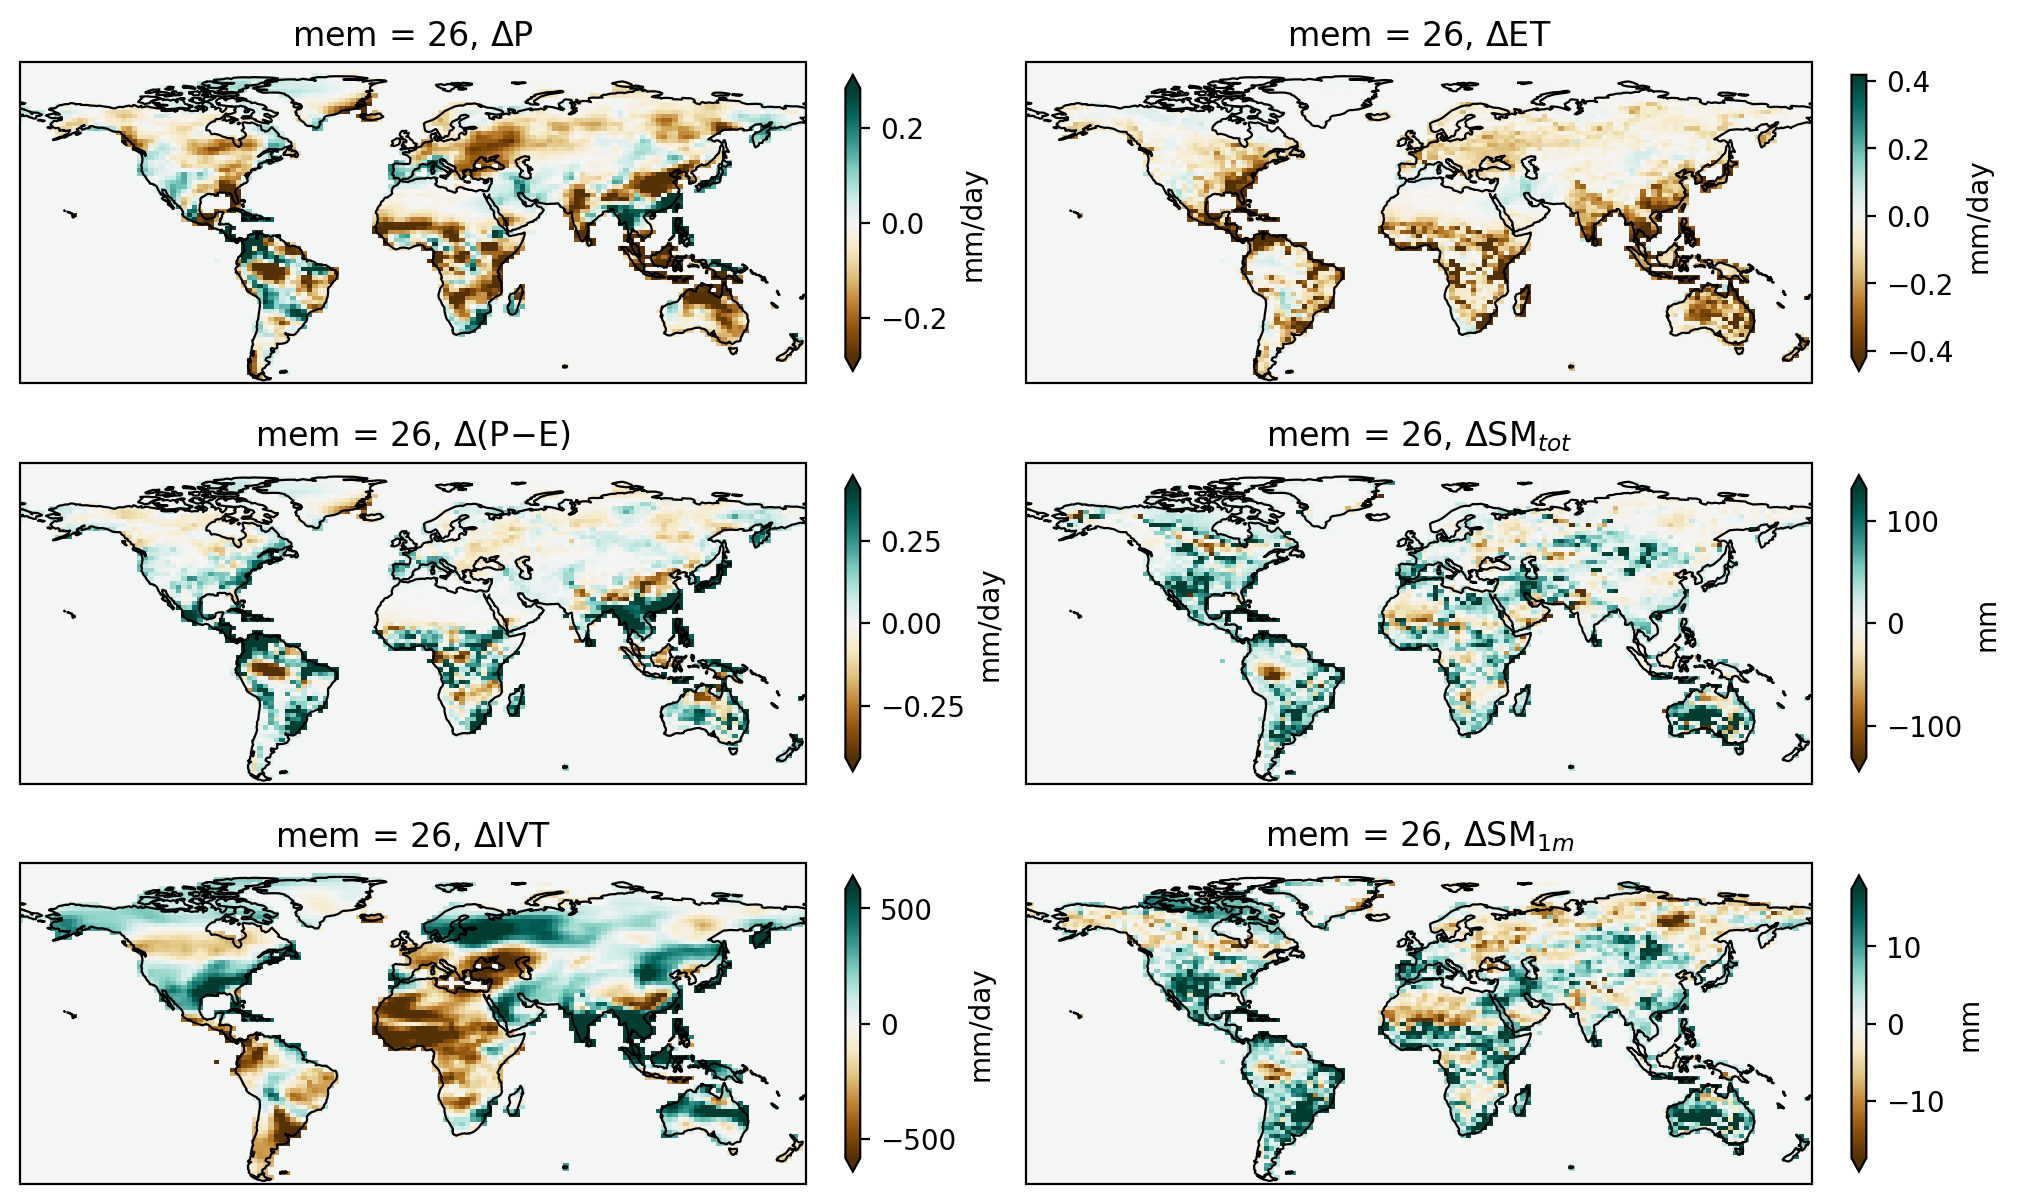

In [110]:
plot_water_budget_difference(26, dpi=200)

In [109]:
# plot_water_budget_difference(25, dpi=200)